#                                                       ML PROJECT

### 1 - INTRODUCTION

Description...............................

### 2 - IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

### 3 - LOADING DATASETS

In [2]:
# Loading them into dataframes for easy manipulations

fs1 = pd.read_csv("data/FS1.txt", sep="\t", header=None)
ps2 = pd.read_csv("data/PS2.txt", sep="\t", header=None)
profile = pd.read_csv("data/profile.txt", sep="\t", header=None)

# extraction 
valve_condition = profile.iloc[:,1]

In [3]:
fs1.head(5)

,0,1,2,3,4,5,6,7,8,9,...,590,591,592,593,594,595,596,597,598,599
0,8.990,0.770,0.641,0.006,0.000,0.000,0.001,0.003,0.001,0.001,...,7.743,7.992,7.919,7.773,7.955,7.823,7.963,7.876,7.738,8.036
1,8.919,0.815,0.709,0.009,0.004,0.000,0.001,0.000,0.000,0.001,...,7.831,8.003,7.923,7.745,7.867,7.747,7.969,7.969,7.963,7.890
2,9.179,0.683,0.528,0.008,0.003,0.001,0.003,0.003,0.004,0.006,...,7.862,7.815,7.894,7.743,7.936,7.770,7.982,7.873,7.898,7.952
3,9.034,0.728,0.595,0.009,0.001,0.004,0.003,0.003,0.003,0.001,...,7.631,7.949,7.773,8.054,7.827,8.011,7.919,7.938,7.877,7.773
4,8.729,0.705,0.446,0.014,0.007,0.003,0.001,0.003,0.001,0.000,...,7.771,7.936,7.919,7.946,7.804,7.983,7.838,7.882,7.894,7.825


In [4]:
ps2.head(5)

,0,1,2,3,4,5,6,7,8,9,...,5990,5991,5992,5993,5994,5995,5996,5997,5998,5999
0,125.50,125.39,125.40,125.03,124.05,123.18,104.01,56.500,23.992,18.406,...,125.02,125.00,125.10,125.09,124.98,124.91,124.98,125.11,125.14,125.10
1,125.06,125.08,125.09,124.69,123.84,123.14,103.63,63.687,28.359,21.711,...,124.80,124.88,125.13,125.22,125.09,124.98,125.06,125.13,125.09,125.04
2,125.13,125.27,125.23,124.74,123.94,123.23,106.35,60.516,26.258,19.258,...,124.61,124.69,124.74,124.71,124.59,124.64,124.74,124.73,124.77,124.88
3,124.93,124.96,124.92,124.41,123.60,122.88,103.99,58.859,27.781,21.469,...,124.82,124.79,124.69,124.69,124.77,124.83,124.69,124.53,124.51,124.59
4,124.72,124.74,124.66,124.31,123.57,122.74,105.94,62.648,30.875,23.883,...,124.80,124.67,124.49,124.56,124.69,124.62,124.45,124.41,124.47,124.51


In [5]:
print(valve_condition.shape)
valve_condition.head(5)

(2205,)


0    100
1    100
2    100
3    100
4    100
Name: 1, dtype: int64

### 4 - UNDERSTANDING THE DATA

In [6]:
print("FS1 shape:", fs1.shape)
print("PS2 shape:", ps2.shape)
print("Valve condition shape:", valve_condition.shape)

FS1 shape: (2205, 600)
PS2 shape: (2205, 6000)
Valve condition shape: (2205,)


In [7]:
print("Number of cycles in FS1:", len(fs1))
print("Number of cycles in PS2:", len(ps2))
print("Number of target values:", len(valve_condition))
print("\nSame number of cycles:",
      len(fs1) == len(ps2) == len(valve_condition))

Number of cycles in FS1: 2205
Number of cycles in PS2: 2205
Number of target values: 2205

Same number of cycles: True


Comme nos deux datasets contienent le meme nombre de cycle, on peut conclure que chaque cycle de PS2 doit correspondre a un cycle FS1 et a une valeur de valve_condition. Donc on peut concatener nos donnees sur les lignes.

In [8]:
print("FS1 data types:")
print(fs1.dtypes.value_counts())
print("\nPS2 data types:")
print(ps2.dtypes.value_counts())
print("\nValve condition type:")
print(valve_condition.dtype)

FS1 data types:
float64    600
Name: count, dtype: int64

PS2 data types:
float64    6000
Name: count, dtype: int64

Valve condition type:
int64


On conclu que les capteur sont bien numeriques

In [9]:
print("Valve condition unique values:")
print(np.sort(valve_condition.unique()))

Valve condition unique values:
[ 73  80  90 100]


Notre base de donnees contient 2205 cycles de functionnement. Chaque ligne represent un cycle de fonctionnement complet de notre system hydraulique.
- PS2.txt contient les donnees du cateur de Pression "PS2" en bar avec une frequence de 100 Hz dans la valve
- FS1.txt contient les donnees du capteur de debit volumique "FS1" en l/min avec une frequence de 10Hz dans la valve
- valve_condition contient les donnees des coditions de fonctionnement de la valve

### 5 - DESCRIPTIVE STATISTIQUES

In [10]:
fs1.describe()

,0,1,2,3,4,5,6,7,8,9,...,590,591,592,593,594,595,596,597,598,599
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,8.287100,0.857298,0.563584,0.031154,0.003567,0.002926,0.002683,0.002458,0.002436,0.002311,...,7.638567,7.638928,7.642123,7.641907,7.638804,7.643067,7.637415,7.645035,7.638999,7.637983
std,0.480969,0.125100,0.152903,0.039403,0.002810,0.002540,0.002501,0.002410,0.002451,0.002378,...,0.530204,0.529731,0.530209,0.530325,0.529648,0.530317,0.529648,0.530884,0.530817,0.529553
min,7.033000,0.522000,0.309000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.106000,1.117000,1.119000,1.123000,1.109000,1.111000,1.118000,1.120000,1.124000,1.120000
25%,7.961000,0.773000,0.445000,0.009000,0.001000,0.001000,0.000000,0.000000,0.000000,0.000000,...,7.514000,7.515000,7.518000,7.515000,7.519000,7.518000,7.513000,7.525000,7.510000,7.519000
50%,8.278000,0.855000,0.531000,0.016000,0.003000,0.003000,0.003000,0.001000,0.001000,0.001000,...,7.712000,7.709000,7.711000,7.714000,7.706000,7.714000,7.707000,7.713000,7.710000,7.708000
75%,8.610000,0.944000,0.656000,0.036000,0.005000,0.004000,0.004000,0.004000,0.004000,0.004000,...,7.815000,7.815000,7.818000,7.823000,7.813000,7.820000,7.813000,7.821000,7.826000,7.815000
max,11.754000,1.488000,0.985000,0.298000,0.015000,0.013000,0.011000,0.011000,0.012000,0.012000,...,8.060000,8.078000,8.072000,8.064000,8.073000,8.080000,8.076000,8.083000,8.078000,8.087000


In [11]:
ps2.describe()

,0,1,2,3,4,5,6,7,8,9,...,5990,5991,5992,5993,5994,5995,5996,5997,5998,5999
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,123.362422,123.364358,123.339202,122.831868,121.808503,120.693455,104.294819,64.491438,35.220531,27.355589,...,123.359583,123.356580,123.355896,123.360023,123.361705,123.358848,123.358966,123.364444,123.364957,123.361741
std,3.701729,3.694412,3.700527,3.819922,3.746546,3.541433,9.616892,8.636717,3.792106,3.286553,...,3.701453,3.705096,3.702194,3.701239,3.698299,3.694301,3.700553,3.703952,3.700664,3.703531
min,119.610000,119.630000,118.920000,118.650000,115.830000,97.289000,27.031000,0.977000,1.133000,1.203000,...,119.140000,119.630000,119.680000,119.590000,119.690000,119.520000,119.650000,119.650000,119.600000,119.520000
25%,121.630000,121.670000,121.660000,120.560000,118.830000,117.690000,96.664000,58.883000,33.398000,25.523000,...,121.630000,121.650000,121.670000,121.660000,121.660000,121.670000,121.670000,121.650000,121.630000,121.630000
50%,123.040000,123.040000,123.010000,122.620000,122.060000,121.520000,105.080000,64.773000,35.180000,27.398000,...,123.040000,123.040000,123.060000,123.030000,123.030000,123.030000,123.020000,123.020000,123.020000,123.040000
75%,125.100000,125.100000,125.090000,124.830000,124.480000,124.270000,113.020000,71.297000,37.289000,29.266000,...,125.100000,125.120000,125.110000,125.120000,125.110000,125.090000,125.100000,125.110000,125.130000,125.110000
max,165.480000,165.260000,165.530000,165.690000,160.570000,125.220000,117.390000,79.102000,44.617000,35.398000,...,165.570000,165.730000,165.560000,165.350000,165.440000,165.430000,165.440000,165.630000,165.360000,165.340000


Nous procedons ensuite par analyser valve condition

In [12]:
valve_condition.value_counts().sort_index()

1
73      360
80      360
90      360
100    1125
Name: count, dtype: int64

In [13]:
valve_distribution = pd.DataFrame({
    "Count": valve_condition.value_counts().sort_index(),
    "Percentage": valve_condition.value_counts(normalize=True)
                                  .sort_index()
                                  .mul(100)
                                  .round(2)
})

valve_distribution

,Count,Percentage
1,,
73,360,16.33
80,360,16.33
90,360,16.33
100,1125,51.02


In [14]:
# Sensor summary for all the data in the dataset
sensor_summary = pd.DataFrame({
    "PS2": pd.Series(ps2.to_numpy().ravel()).describe(),
    "FS1": pd.Series(fs1.to_numpy().ravel()).describe()
})
sensor_summary

,PS2,FS1
count,1.323000e+07,1.323000e+06
mean,1.093799e+02,6.198549e+00
std,4.810317e+01,3.213827e+00
min,0.000000e+00,0.000000e+00
25%,1.185400e+02,7.339000e+00
50%,1.257000e+02,7.641000e+00
75%,1.304100e+02,7.796000e+00
max,1.677700e+02,2.047900e+01


### 6 - MISSING VALUES & OUTLIER ANALYSIS

Verification des valeurs manquantes

In [15]:
missing_values = pd.DataFrame({
    "Dataset": ["PS2", "FS1", "Valve Condition"],
    "Missing Values": [
        ps2.isna().sum().sum(),
        fs1.isna().sum().sum(),
        valve_condition.isna().sum()
    ]
})
missing_values

,Dataset,Missing Values
0,PS2,0
1,FS1,0
2,Valve Condition,0


Nous constatons que nous n'avons pas de valeur manquantes dans notre base de donnees. Donc, nous pouvons proceder a la verification des outliers et des valeurs aberrantes.

In [16]:
print("Infinite values in PS2:",
      np.isinf(ps2.to_numpy()).sum())

print("Infinite values in FS1:",
      np.isinf(fs1.to_numpy()).sum())

Infinite values in PS2: 0
Infinite values in FS1: 0


In [17]:
print("Duplicate PS2 cycles:", ps2.duplicated().sum())
print("Duplicate FS1 cycles:", fs1.duplicated().sum())

Duplicate PS2 cycles: 0
Duplicate FS1 cycles: 0


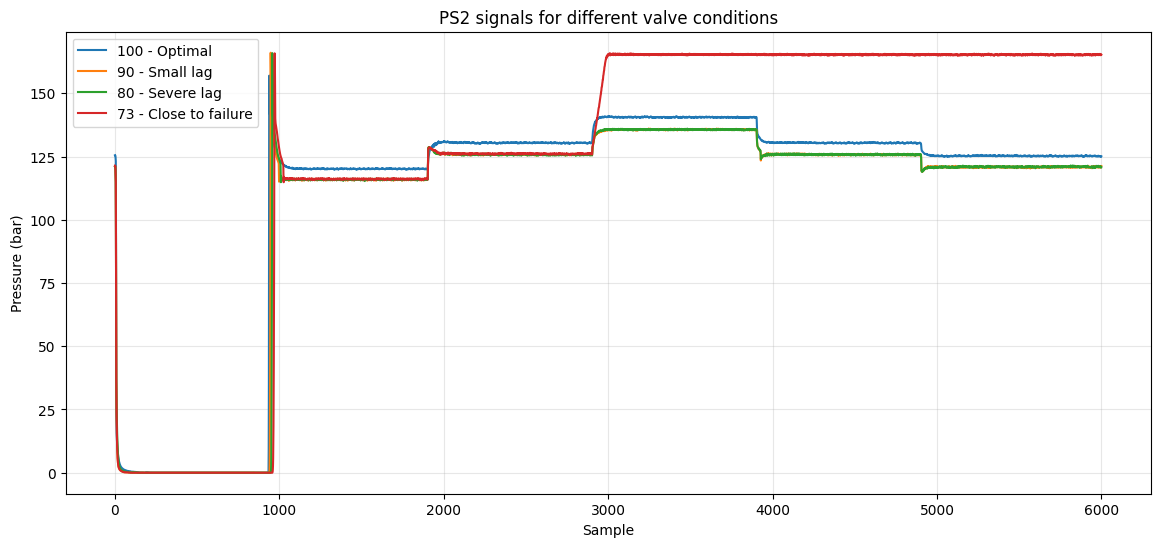

In [18]:
# Coourbe de la pression pour les 5 premier cycles pour visualiser les donnees
# Valve conditions
conditions = [100, 90, 80, 73]
condition_labels = { 100: "Optimal", 90: "Small lag", 80: "Severe lag", 73: "Close to failure"}
plt.figure(figsize=(14, 6))
for condition in conditions:
    cycle_index = valve_condition[
        valve_condition == condition].index[0]
    plt.plot(
        ps2.iloc[cycle_index],
        label=f"{condition} - {condition_labels[condition]}")
plt.title("PS2 signals for different valve conditions")
plt.xlabel("Sample")
plt.ylabel("Pressure (bar)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

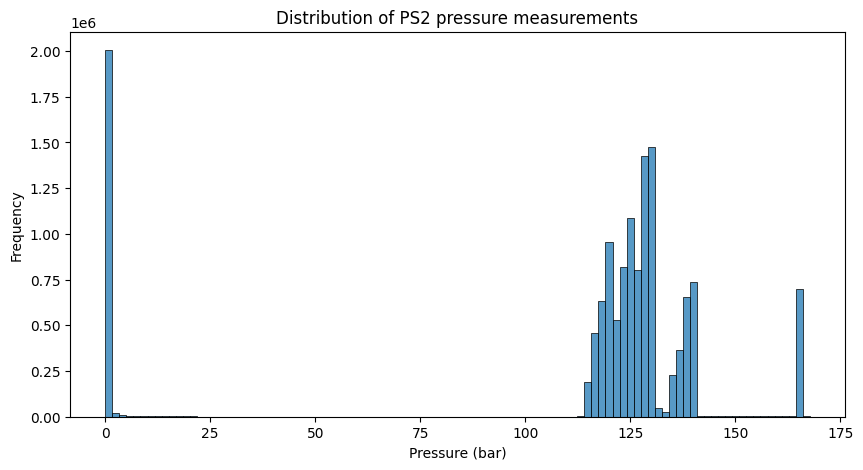

In [19]:
# Distribution des donnees de pressions du capteur PS2
plt.figure(figsize=(10, 5))
sns.histplot(
    ps2.to_numpy().ravel(),
    bins=100
)
plt.title("Distribution of PS2 pressure measurements")
plt.xlabel("Pressure (bar)")
plt.ylabel("Frequency")
plt.show()

On constate que nous avons une distribution assez irregulier. Nous avons un pic de valeur proche de 0 et une distribution de donnees entre 100 - 175.
Cette distribution de donnnees et du aux fonctions mechanique de notre valve. Nous avons des cycles de chargement et de dechargement qui font fluctuer les valeur de pressions de la valve.
Nous avons aucune valuer negative ni aucun outlier ce qui confirme que notre dataset PS2 est conform

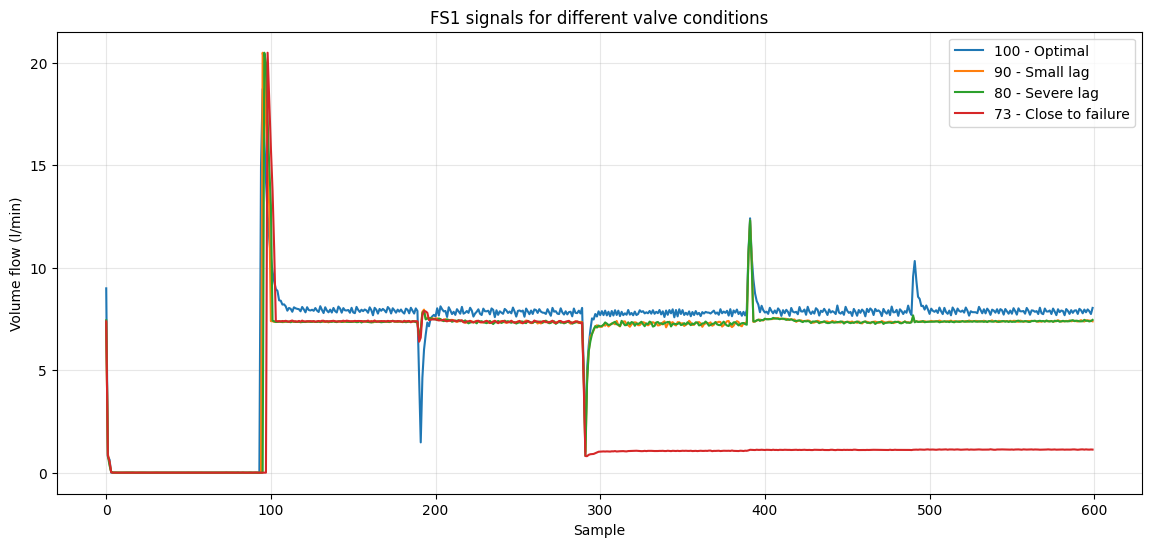

In [20]:
# Coourbe du debit volumique pour le premier cycle pour visualiser les donnees
plt.figure(figsize=(14, 6))
for condition in conditions:
    cycle_index = valve_condition[
        valve_condition == condition].index[0]
    plt.plot(
        fs1.iloc[cycle_index],
        label=f"{condition} - {condition_labels[condition]}")
plt.title("FS1 signals for different valve conditions")
plt.xlabel("Sample")
plt.ylabel("Volume flow (l/min)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

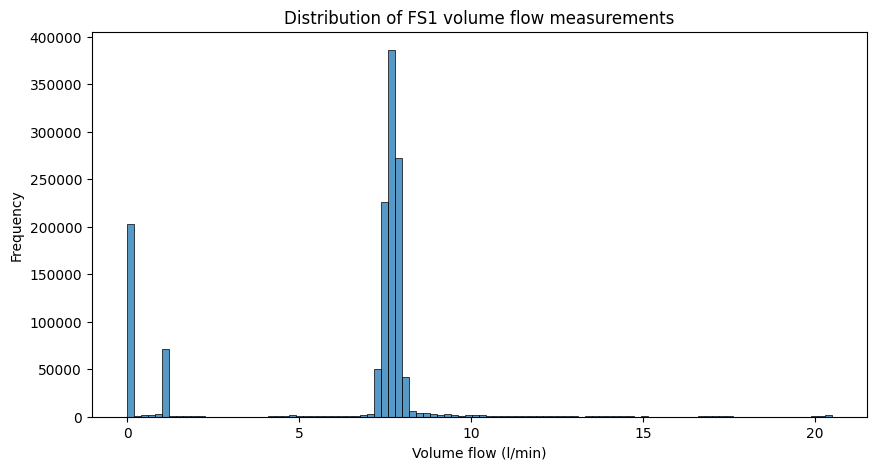

In [21]:
# Distribution des donnees du debit volumique
plt.figure(figsize=(10, 5))
sns.histplot(
    fs1.to_numpy().ravel(),
    bins=100
)
plt.title("Distribution of FS1 volume flow measurements")
plt.xlabel("Volume flow (l/min)")
plt.ylabel("Frequency")
plt.show()

Commen les ces donnees representent un systeme mechanique qui opere avec des differentes phase durant un cycle(chargement et dechargement), les distributions ne suivent pas une loi normale.
Ainsi, les valuers extremes observe sont conserve et sont pas consideres comme des outliers car elles decrivent les systeme.

### 7 - FEATURE ENGINEERING

Grace a la documentation, nous comprenons que les donnees sont formatees d'une facon non conventionnnelle. Le donnees sont enregistré par cycle et enregiste sur une meme ligne avec une frequence d'echantillonage. Donc une ligne representre les donnees enregistre pour un cycle complet. 

Pour un cycle complet, on a : 
- Pression (PS2) avec pour frequence 100 Hz: 60 seconds * 100 mesures/seconds = 6000 mesures.
- Debit volumique (FS1) avec pour frequence 10 Hz: 60 seconds * 10 mesures/seconds = 600 mesures
Ca correspond exactement aux nombre de colonnes de nos dataset respectives

Donc nous devons proceder aux traitement des donnees pour rendre les donnees exploitable.
On traite des donness brutes des capteurs comme des signaux. Nous allons proceder a la transformation des ces donnes pour extraires des features exploitable par notre model. Nous alons utilise 
-Des statistiques simples
-Des caractéristiques temporelles
-Des caractéristiques fréquentielles (FFT)
-Des caractéristiques de forme (peaks)
-Des caractéristiques glissantes (rolling)
De notre signal pour chaque cycle

Ainsi, nous alons tester tout ces features pour evaluer notre model et ses performances

In [ ]:
# Implementation d'une fonction qui permet de generer des features telles que la moyenne,ecart-type,min, max etc. 
from scipy.signal import find_peaks
def extract_features(df, prefix, sampling_rate):
    features = pd.DataFrame(index=df.index)
    # Basic statistical features
    features[f"{prefix}_mean"] = df.mean(axis=1)
    features[f"{prefix}_median"] = df.median(axis=1)
    features[f"{prefix}_std"] = df.std(axis=1)
    features[f"{prefix}_min"] = df.min(axis=1)
    features[f"{prefix}_max"] = df.max(axis=1)
    features[f"{prefix}_range"] = (
        features[f"{prefix}_max"]
        - features[f"{prefix}_min"])
    features[f"{prefix}_mean_abs_change"] = (
        df.diff(axis=1)
          .abs()
          .mean(axis=1))
    # Advanced features
    energy = []
    entropy_values = []
    dominant_frequencies = []
    peak_counts = []
    rolling_mean_std = []
    rolling_std_max = []
    window_size = sampling_rate
    for _, row in df.iterrows():
        signal = row.to_numpy()
        # Signal energy
        energy.append(
            np.mean(signal ** 2)
        )
        # FFT
        centered_signal = signal - np.mean(signal)
        fft_values = np.fft.rfft(centered_signal)
        power = np.abs(fft_values) ** 2
        frequencies = np.fft.rfftfreq(
            len(signal),
            d=1 / sampling_rate
        )
        # Ignore frequency = 0
        power = power[1:]
        frequencies = frequencies[1:]
        # Dominant frequency
        dominant_frequencies.append(
            frequencies[np.argmax(power)]
        )
        # Spectral entropy
        probability = power / (
            power.sum() + 1e-12
        )
        entropy = -np.sum(
            probability *
            np.log2(probability + 1e-12)
        )
        entropy = entropy / np.log2(
            len(probability)
        )
        entropy_values.append(entropy)
        # Peak detection
        peaks, _ = find_peaks(
            signal,
            prominence=0.5 * np.std(signal)
        )
        peak_counts.append(len(peaks))
        # Rolling window features
        signal_series = pd.Series(signal)

        rolling_mean = signal_series.rolling(
            window=window_size
        ).mean()
        rolling_std = signal_series.rolling(
            window=window_size
        ).std()
        rolling_mean_std.append(
            rolling_mean.std()
        )
        rolling_std_max.append(
            rolling_std.max()
        )
    features[f"{prefix}_energy"] = energy
    features[f"{prefix}_spectral_entropy"] = entropy_values
    features[f"{prefix}_dominant_frequency"] = dominant_frequencies
    features[f"{prefix}_peak_count"] = peak_counts
    features[f"{prefix}_rolling_mean_std"] = rolling_mean_std
    features[f"{prefix}_rolling_std_max"] = rolling_std_max

    return features

In [23]:
ps2_features = extract_features(
    ps2,
    prefix="PS2",
    sampling_rate=100)
fs1_features = extract_features(
    fs1,
    prefix="FS1",
    sampling_rate=10)
print("PS2 features shape:", ps2_features.shape)
print("FS1 features shape:", fs1_features.shape)

PS2 features shape: (2205, 13)
FS1 features shape: (2205, 13)


In [24]:
X = pd.concat(
    [ps2_features, fs1_features],
    axis=1)
X.head()

,PS2_mean,PS2_median,PS2_std,PS2_min,PS2_max,PS2_range,PS2_mean_abs_change,PS2_energy,PS2_spectral_entropy,PS2_dominant_frequency,...,FS1_min,FS1_max,FS1_range,FS1_mean_abs_change,FS1_energy,FS1_spectral_entropy,FS1_dominant_frequency,FS1_peak_count,FS1_rolling_mean_std,FS1_rolling_std_max
0,109.466914,129.365,47.114508,0.0,156.99,156.99,0.117134,14202.412025,0.237172,0.016667,...,0.0,18.710,18.710,0.256631,54.099268,0.467683,0.016667,4,2.827221,8.367210
1,109.354890,129.385,47.045611,0.0,157.56,157.56,0.120195,14171.412675,0.237185,0.016667,...,0.0,18.712,18.712,0.247778,54.117921,0.457191,0.016667,4,2.830642,7.959359
2,109.158845,129.325,46.992060,0.0,156.97,156.97,0.123362,14123.539055,0.237149,0.016667,...,0.0,18.698,18.698,0.251705,54.209083,0.462013,0.016667,4,2.832054,8.099865
3,109.064807,128.865,46.972221,0.0,156.44,156.44,0.125399,14101.154022,0.237032,0.016667,...,0.0,18.896,18.896,0.249077,54.272252,0.466355,0.016667,4,2.832145,8.299677
4,108.931434,129.000,46.874946,0.0,158.13,158.13,0.127465,14062.951759,0.236902,0.016667,...,0.0,18.876,18.876,0.249613,53.814545,0.460357,0.016667,4,2.827509,8.058890


In [25]:
# Verifier si les donnees ont ete bien generé
print("Missing values in engineered features:")
print(X.isna().sum().sum())
print("\nInfinite values:")
print(np.isinf(X.to_numpy()).sum())
print("\nDuplicated feature rows:")
print(X.duplicated().sum())

Missing values in engineered features:
0

Infinite values:
0

Duplicated feature rows:
0


Verification de la variance des features, pour identier des features constats qui n'apporte aucune information a notre base de donnees

In [26]:
feature_variance = X.var()
constant_features = feature_variance[
    feature_variance == 0
]
constant_features

PS2_min                   0.0
PS2_dominant_frequency    0.0
dtype: float64

In [27]:
X = X.drop(columns=constant_features.index)

PS2_min et PS2_dominant_frequency avait une variance nulle, donc elle avait une valeur constante pour chaque cycle. Donc la variable napportait aucune information a notre modele.

In [28]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
PS2_mean,2205.0,1.093799e+02,4.986585,104.406307,106.962382,107.730169,109.421612,131.589089
PS2_median,2205.0,1.286777e+02,3.469525,124.445000,127.215000,127.965000,129.950000,165.400000
PS2_std,2205.0,4.773616e+01,3.271949,45.206954,46.209665,46.805986,47.207567,59.553248
PS2_max,2205.0,1.665205e+02,0.977997,155.040000,166.180000,166.650000,167.100000,167.770000
PS2_range,2205.0,1.665205e+02,0.977997,155.040000,166.180000,166.650000,167.100000,167.770000
PS2_mean_abs_change,2205.0,1.389516e-01,0.029491,0.112485,0.119150,0.130835,0.149416,0.742438
PS2_energy,2205.0,1.427788e+04,1482.552012,12996.973114,13600.565833,13768.195898,14206.139026,20793.922677
PS2_spectral_entropy,2205.0,2.318849e-01,0.018403,0.175172,0.236300,0.238436,0.239046,0.241959
PS2_peak_count,2205.0,1.133787e+00,0.408359,1.000000,1.000000,1.000000,1.000000,4.000000
PS2_rolling_mean_std,2205.0,4.671452e+01,3.306400,44.206108,45.176622,45.785539,46.145379,58.555433


### Creation du target (binaire)

Comme notre tache concerne une classification binaire, nous devons standardiser les donnees de valve condition pour avoir deux classe pour notre classification.
D'apres notre documentation, on a :
100 = functionnement optimal. Donc on lui attribue la classe 0
et different de 100 = functionnement non-optimale. Donc on lui attribue la classe de 1

In [29]:
y = (valve_condition != 100).astype(int)
y.value_counts().sort_index()

1
0    1125
1    1080
Name: count, dtype: int64

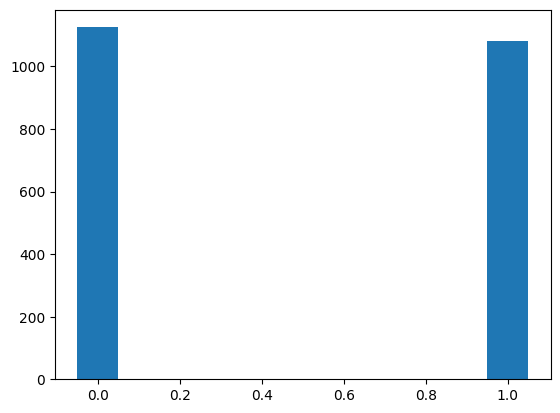

In [30]:
# Distribution of the target variables in our dataset
from collections import Counter
histogram = Counter(y)
plt.bar(histogram.keys(), histogram.values(),0.1)
plt.show()


In [31]:
target_distribution = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percentage": (
        y.value_counts(normalize=True)
         .sort_index()
         .mul(100)
         .round(2)
    )
})
target_distribution.index = ["Optimal (0)", "Non-optimal (1)"]
target_distribution

,Count,Percentage
Optimal (0),1125,51.02
Non-optimal (1),1080,48.98


Nous constatons que les classes sont assez equilibre dans notre dataset. Ceci nous garantit que d'avoir des classes equilibres lors de l'entrainement de notre modele

### 7 - SEPARATION DES DONNEES SELON L'ENONCE

Comme specifie durant l'enonce de notre projet, nous alons utliser les 2000 premiers ligne pour entrainer notre modele et le reste pour la validation et pour obtenir nos donnees de test et de validation.

In [32]:
#Separer les 2000 premières lignes
X_main = X.iloc[:2000].copy()
y_main = y.iloc[:2000].copy()

# Split interne pour entraînement et test

X_train, X_test, y_train, y_test = train_test_split(
    X_main, y_main,
    test_size=0.25,
    shuffle=True,
    stratify=y_main,  
    random_state=42
)
#Hold-out final (205 lignes)
X_holdout = X.iloc[2000:].copy()
y_holdout = y.iloc[2000:].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_holdout:", X_holdout.shape)


X_train: (1500, 24)
X_test: (500, 24)
X_holdout: (205, 24)


### 7 - VERIFICATION DE LEQUILIBRE DES CLASSE DANS NOS DONNEES D'ENTRAINEMENT

In [33]:
train_distribution = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Percentage": (
        y_train.value_counts(normalize=True)
               .sort_index()
               .mul(100)
               .round(2)
    )
})
train_distribution.index = ["Optimal (0)", "Non-optimal (1)"]
train_distribution

,Count,Percentage
Optimal (0),789,52.6
Non-optimal (1),711,47.4


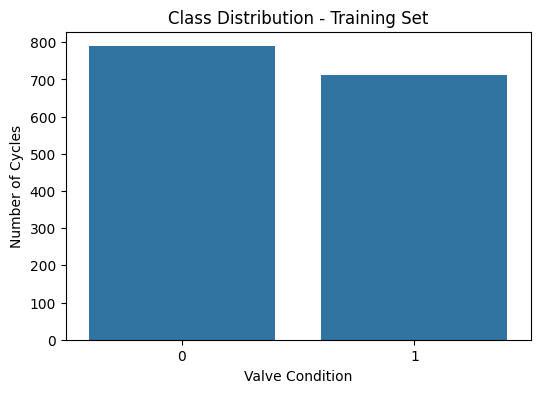

In [34]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Class Distribution - Training Set")
plt.xlabel("Valve Condition")
plt.ylabel("Number of Cycles")
plt.show()

Nous avons une repartition des donnees d'entrainement assez equilibre dans notre base de donnees avec des pourcentages tres proche de 50%

In [35]:
X_train = X_train.drop(columns=["PS2_range","FS1_min","FS1_range"])
X_test = X_test.drop(columns=["PS2_range","FS1_min","FS1_range"])

Nous avons supprime la colonne PS2_rannge car si PS2_min est nulle, alors PS2_range = PS2_max. Donc PS2_range n'apporte aucune information.
De meme FS1_min a des valuer sensiblement proche de 0, donc FS1 range et FS1_max ont une correlation lineaire tres forte. Donc, on supprime aussi FS1_min et FS1_range.

In [36]:
X_train

,PS2_mean,PS2_median,PS2_std,PS2_max,PS2_mean_abs_change,PS2_energy,PS2_spectral_entropy,PS2_peak_count,PS2_rolling_mean_std,PS2_rolling_std_max,...,FS1_median,FS1_std,FS1_max,FS1_mean_abs_change,FS1_energy,FS1_spectral_entropy,FS1_dominant_frequency,FS1_peak_count,FS1_rolling_mean_std,FS1_rolling_std_max
742,106.344960,126.250,45.803888,166.29,0.141627,13406.896893,0.238610,1,44.785948,66.481669,...,7.739,2.989712,20.359,0.198043,52.566682,0.474468,0.016667,4,2.786622,8.601314
303,105.734123,126.020,46.053834,166.12,0.151537,13300.306963,0.236262,1,45.043024,66.337983,...,7.716,3.025119,20.419,0.132481,52.374016,0.490430,0.016667,3,2.794003,9.692357
1363,107.437509,127.750,46.449367,166.63,0.131231,13700.002480,0.238952,1,45.408405,68.487736,...,7.438,2.903551,19.551,0.241803,48.928448,0.481548,0.016667,4,2.697405,8.694907
1619,109.601389,130.090,47.160246,167.32,0.119389,14236.182523,0.239098,1,46.108844,68.406594,...,7.829,2.980356,19.382,0.249359,53.622191,0.448678,0.016667,4,2.811488,7.893516
293,105.547122,126.060,46.327652,166.44,0.150564,13286.088567,0.233791,1,45.342199,65.823046,...,7.732,3.017958,20.479,0.133808,51.959502,0.470986,0.016667,3,2.809173,9.078557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,107.340468,127.440,46.244124,166.45,0.127067,13660.138734,0.239941,1,45.188422,68.225773,...,7.432,2.914131,20.479,0.238898,48.928054,0.490651,0.016667,4,2.699939,8.823557
271,105.503514,125.690,45.896066,165.71,0.153120,13237.089263,0.235735,1,44.915854,66.008390,...,7.467,2.939564,20.479,0.137776,49.087282,0.498505,0.016667,3,2.702365,9.587945
613,122.513147,133.355,57.323268,165.56,0.180340,18294.880599,0.175712,2,56.434844,64.600530,...,1.147,3.513009,20.479,0.153773,22.736761,0.475659,0.050000,2,3.256529,8.358308
61,106.795221,126.980,45.991051,166.23,0.146768,13520.043492,0.238143,1,44.972911,66.907284,...,7.751,2.981692,20.479,0.161245,52.684757,0.468127,0.016667,4,2.788005,8.626986


### JOYCE PART

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score,roc_curve, auc,precision_score,recall_score



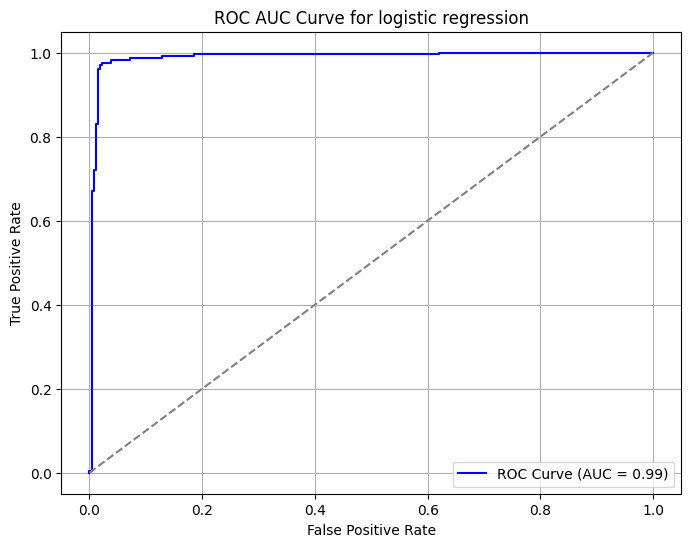

Confusion Matrix:
[[256   7]
 [  6 231]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       263
           1       0.97      0.97      0.97       237

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500

F1 Score: 0.9726315789473684
Accuracy: 0.974
Precision: 0.9705882352941176
recall: 0.9746835443037974


In [38]:
# fonction pour entrainer le modele de regression logistique
def train_logistic_regression(X_train,X_test, y_train, y_test):
    
    #normaliser
    norm=StandardScaler()
    X_train=norm.fit_transform(X_train)
    X_test=norm.transform(X_test)
    
    #entrainer le modele
    model=LogisticRegression(random_state=42)
    model.fit(X_train,y_train)
    
    #prediction
    y_pred=model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Affichage des métriques
    f1=f1_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC Curve for logistic regression')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    
    # Affichage des métriques
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("F1 Score:", f1)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision)
    print("recall:", recall)
    return model
model=train_logistic_regression(X_train,X_test,y_train,y_test)

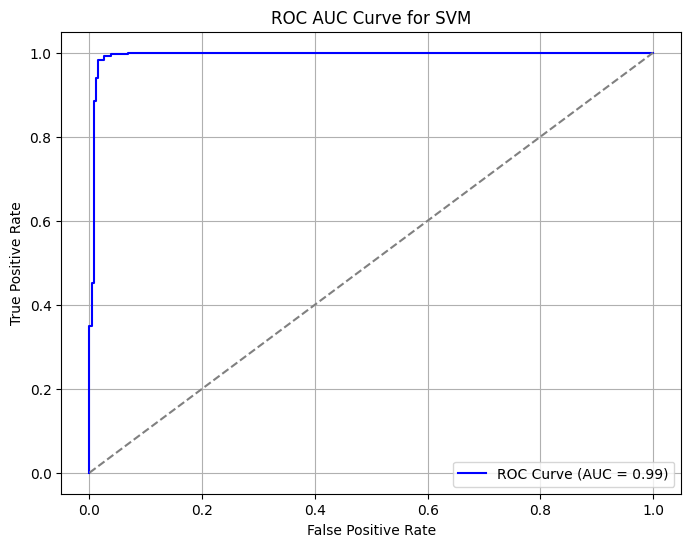

Confusion Matrix:
[[254   9]
 [  2 235]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       263
           1       0.96      0.99      0.98       237

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500

F1 Score: 0.9771309771309772
Accuracy: 0.978
Precision: 0.9631147540983607
recall: 0.9915611814345991


In [39]:
# fonction pour entrainer SVM
def train_svm(X_train,X_test, y_train, y_test):
  

    #normaliser
    norm=StandardScaler()
    X_train=norm.fit_transform(X_train)
    X_test=norm.transform(X_test)

    
    #entrainer le modele
    model=SVC(kernel="rbf", probability=True,random_state=42)
    model.fit(X_train,y_train)
    
    #prediction
    y_pred=model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Affichage des métriques
    f1=f1_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC Curve for SVM')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    
    # Affichage des métriques
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("F1 Score:", f1)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision)
    print("recall:", recall)
    return model
model=train_svm(X_train,X_test, y_train, y_test)

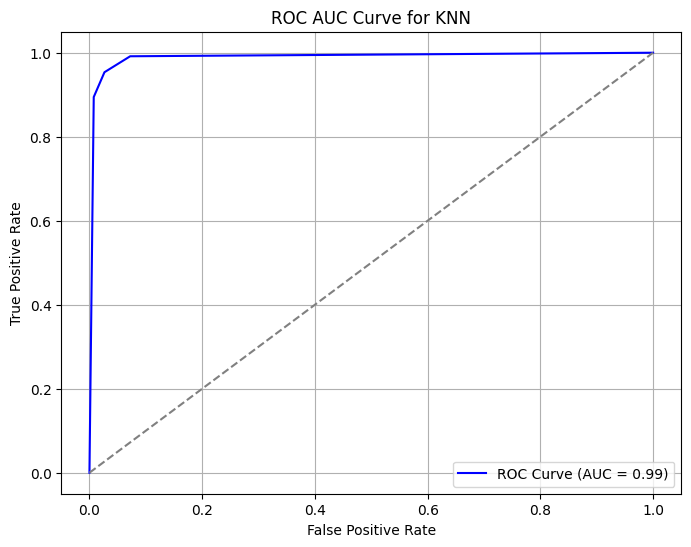

Confusion Matrix:
[[256   7]
 [ 11 226]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       263
           1       0.97      0.95      0.96       237

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500

F1 Score: 0.9617021276595744
Accuracy: 0.964
Precision: 0.9699570815450643
recall: 0.9535864978902954


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [40]:
# fonction pour entrainer SVM


def train_KNN(X_train,X_test, y_train, y_test):
  

    #normaliser
    norm=StandardScaler()
    X_train=norm.fit_transform(X_train)
    X_test=norm.transform(X_test)

    
    #entrainer le modele
    model=KNeighborsClassifier(n_neighbors=3)
    model.fit(X_train,y_train)
    
    #prediction
    y_pred=model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
 
     # Affichage des métriques
    f1=f1_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC Curve for KNN')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()   
    # Affichage des métriques
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("F1 Score:", f1)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision)
    print("recall:", recall)
    return model
model=train_KNN(X_train,X_test, y_train, y_test)
model

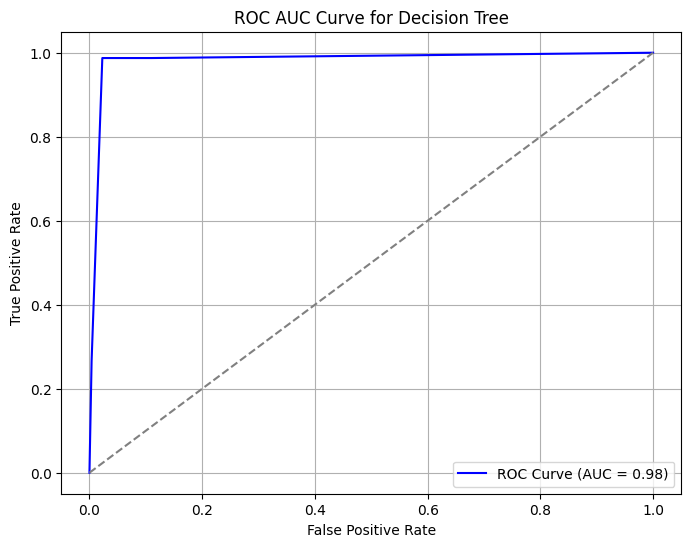

Confusion Matrix:
[[257   6]
 [  3 234]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       263
           1       0.97      0.99      0.98       237

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500

F1 Score: 0.9811320754716981
Accuracy: 0.982
Precision: 0.975
recall: 0.9873417721518988


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [41]:
# fonction pour entrainer SVM

def train_Decision_tree(X_train,X_test, y_train, y_test):
  

    #normaliser
    norm=StandardScaler()
    X_train=norm.fit_transform(X_train)
    X_test=norm.transform(X_test)

    
    #entrainer le modele
    model=DecisionTreeClassifier(max_depth=5,random_state=42)
    model.fit(X_train,y_train)
    
    #prediction
    y_pred=model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Affichage des métriques
    f1=f1_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC Curve for Decision Tree')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("F1 Score:", f1)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision)
    print("recall:", recall)
    return model
model=train_Decision_tree(X_train,X_test, y_train, y_test)
model

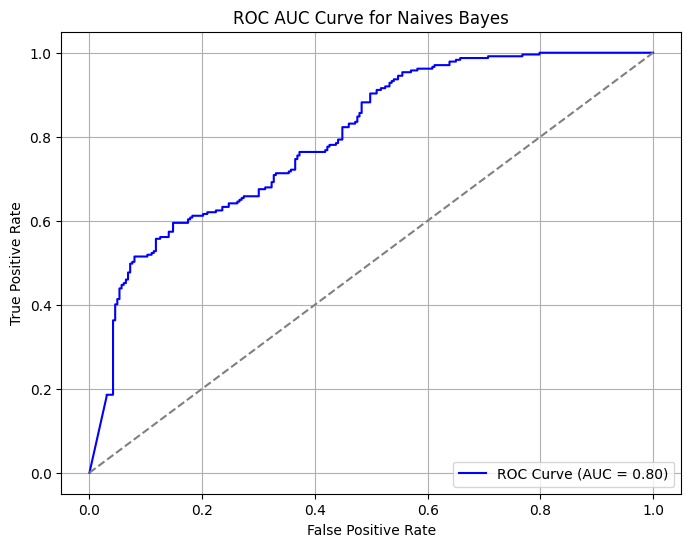

Confusion Matrix:
[[252  11]
 [167  70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.96      0.74       263
           1       0.86      0.30      0.44       237

    accuracy                           0.64       500
   macro avg       0.73      0.63      0.59       500
weighted avg       0.73      0.64      0.60       500

F1 Score: 0.44025157232704404
Accuracy: 0.644
Precision: 0.8641975308641975
recall: 0.29535864978902954


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [42]:
# fonction pour entrainer Naives bayes


def train_naive_bayes(X_train,X_test, y_train, y_test):
  

    #normaliser
    norm=StandardScaler()
    X_train=norm.fit_transform(X_train)
    X_test=norm.transform(X_test)

    
    #entrainer le modele
    model=GaussianNB()
    model.fit(X_train,y_train)
    
    #prediction
    y_pred=model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
 
     # Affichage des métriques
    f1=f1_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC Curve for Naives Bayes')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()   
    # Affichage des métriques
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("F1 Score:", f1)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision)
    print("recall:", recall)
    return model
model=train_naive_bayes(X_train,X_test, y_train, y_test)
model

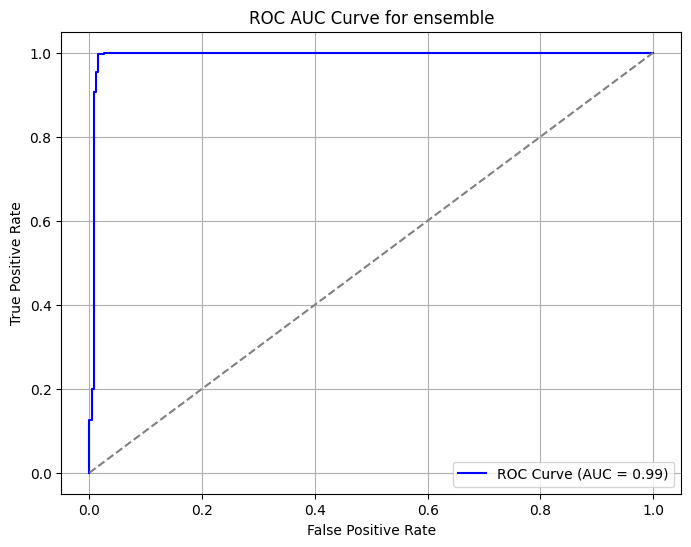

Confusion Matrix:
[[259   4]
 [  2 235]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       263
           1       0.98      0.99      0.99       237

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500

F1 Score: 0.9873949579831933
Accuracy: 0.988
Precision: 0.9832635983263598
recall: 0.9915611814345991


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('svm', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [43]:
# ensemble learning


def train_ensemble(X_train,X_test, y_train, y_test):
  

    #normaliser
    norm=StandardScaler()
    X_train=norm.fit_transform(X_train)
    X_test=norm.transform(X_test)

    
    #entrainer le modele
    model=VotingClassifier(
      estimators=[
        ('lr', LogisticRegression()),
        ('svm', SVC(probability=True)),
        ('knn', KNeighborsClassifier()),
        ('dt', DecisionTreeClassifier()),
        ('nb', GaussianNB())
    ],
    voting='soft'  # utilise les probabilités
)
    model.fit(X_train,y_train)
    
    #prediction
    y_pred=model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
 
     # Affichage des métriques
    f1=f1_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC Curve for ensemble')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()   
    # Affichage des métriques
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("F1 Score:", f1)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision)
    print("recall:", recall)
    return model
model=train_ensemble(X_train,X_test, y_train, y_test)
model

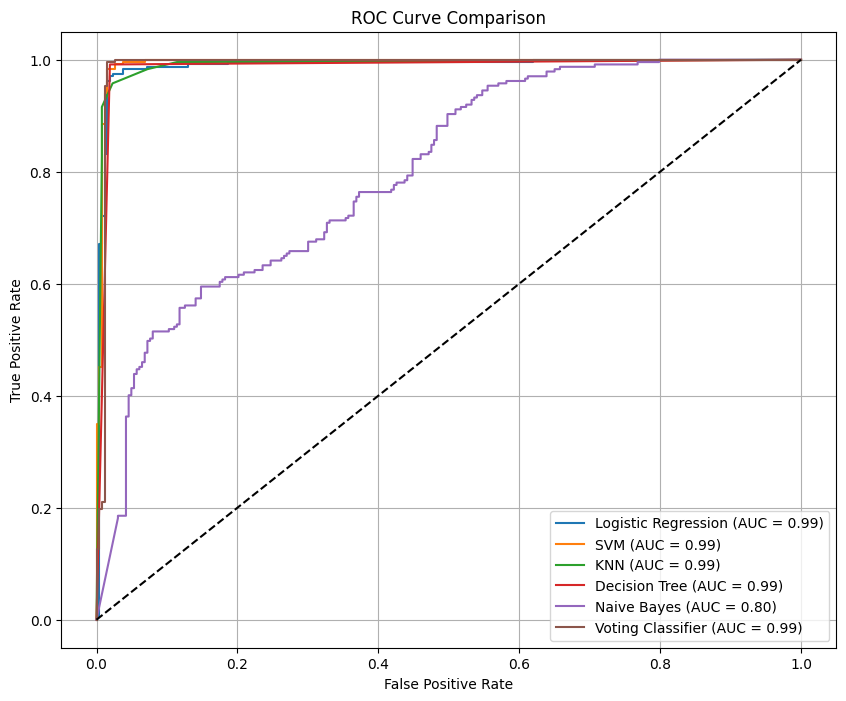

                 Model  Accuracy  Precision    Recall  F1-score       AUC
0  Logistic Regression     0.974   0.970588  0.974684  0.972632  0.989010
1                  SVM     0.978   0.963115  0.991561  0.977131  0.994369
2                  KNN     0.968   0.974249  0.957806  0.965957  0.990807
3        Decision Tree     0.986   0.979167  0.991561  0.985325  0.986275
4          Naive Bayes     0.644   0.864198  0.295359  0.440252  0.798078
5    Voting Classifier     0.988   0.983264  0.991561  0.987395  0.990406


In [44]:

models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "Voting Classifier": VotingClassifier(
      estimators=[
        ('lr', LogisticRegression()),
        ('svm', SVC(probability=True)),
        ('knn', KNeighborsClassifier()),
        ('dt', DecisionTreeClassifier()),
        ('nb', GaussianNB())
    ],
    voting='soft'  # utilise les probabilités
)
}

metrics = []  # tableau des métriques

plt.figure(figsize=(10, 8))
norm=StandardScaler()
X_train=norm.fit_transform(X_train)
X_test=norm.transform(X_test)
for name, model in models.items():
    
    # entraîner
    model.fit(X_train, y_train)

    # prédictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # tracer la courbe ROC
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

    # calcul des métriques
    metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc
    })

# courbe random
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

# tableau des métriques
df_metrics = pd.DataFrame(metrics)
print(df_metrics)



In [45]:
def analyse_biais_variance(df_metrics):
    analyses = []

    for _, row in df_metrics.iterrows():
        model = row["Model"]
        acc = row["Accuracy"]
        prec = row["Precision"]
        rec = row["Recall"]
        f1 = row["F1-score"]
        auc = row["AUC"]

        # Détection du biais
        biais = "faible"
        if rec < 0.60 or auc < 0.70:
            biais = "élevé"
        elif rec < 0.75:
            biais = "modéré"

        # Détection de la variance
        variance = "faible"
        if acc == 1.0 or auc == 1.0:
            variance = "élevée"
        elif acc > 0.90:
            variance = "modérée"

        # Compromis
        if biais == "faible" and variance == "faible":
            compromis = "excellent"
        elif biais == "modéré" and variance == "modéré":
            compromis = "bon"
        elif biais == "élevé":
            compromis = "mauvais (biais)"
        else:
            compromis = "instable (variance)"

        analyses.append({
            "Model": model,
            "Biais": biais,
            "Variance": variance,
            "Compromis": compromis
        })

    return pd.DataFrame(analyses)

analyse_biais_variance(df_metrics)

,Model,Biais,Variance,Compromis
0,Logistic Regression,faible,modérée,instable (variance)
1,SVM,faible,modérée,instable (variance)
2,KNN,faible,modérée,instable (variance)
3,Decision Tree,faible,modérée,instable (variance)
4,Naive Bayes,élevé,faible,mauvais (biais)
5,Voting Classifier,faible,modérée,instable (variance)


In [46]:
#GridSearch

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best params LR:", grid_lr.best_params_)
print("Best score LR:", grid_lr.best_score_)

Best params LR: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best score LR: 0.9849199702409992


c:\Users\koudj_wkfw7eh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [47]:
param_grid_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"]
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid_svm,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Best params SVM:", grid_svm.best_params_)
print("Best score SVM:", grid_svm.best_score_)

Best params SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best score SVM: 0.989172085120505


In [48]:
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Best params KNN:", grid_knn.best_params_)
print("Best score KNN:", grid_knn.best_score_)

Best params KNN: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best score KNN: 0.9788576809251947


In [49]:

param_grid_dt = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid_dt,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best params DT:", grid_dt.best_params_)
print("Best score DT:", grid_dt.best_score_)


Best params DT: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}
Best score DT: 0.9705936153985519
